# Le réchauffement climatique

On va tenter de répondre dans ce projet à une question : des mesures de température mesurées localement au cours du dernier siècle mettent-elles en évidence un réchauffement significatif ? On va travailler pour répondre à cette question sur les relevés de température enregistrés quotidiennement depuis juin 1920 à [la station météorologique de Montélimar](https://donneespubliques.meteofrance.fr/metadonnees_publiques/fiches/fiche_26198001.pdf). Elles peuvent être téléchargées librement depuis le [site de l'ECAD](https://www.ecad.eu/) (European Climate Assessment & Dataset).

Vous trouverez dans le fichier *montelimar_temperature.dat* un fichier de données préparées avec :
- colonne 1 : date en MJD (*modified Julian Day*)
- colonne 2 : température en degrés Celsius


La première problématique à laquelle vous êtes confrontés est de faire apparaître un effet faible et lent (on voit dans la figure ci-dessus que le réchauffement est de l'ordre de 1 °C sur les 30 dernières dernières années) à l'échelle des données (amplitudes de fluctuations quotidiennes ou saisonnières dix fois supérieures typiquement).

La seconde problématique est de montrer que l'effet observé est significatif, c'est-à-dire que cette augmentation des températures ne correspond pas à une fluctuation statistique. Pour cela on supposera que l'erreur sur les mesures de température est de l'ordre de 5 °C. C'est l'ordre de grandeur des fluctuations quotidiennes qui ne seront pas prises en compte dans un modèle qui décrit des variations saisonnières.

Les variations saisonnières de la température peuvent être modélisée par une sinusoïde de période une année. Il faut utiliser un modèle du type sinusoïdal :

$$ T(t) = A \sin{(\omega t + \phi)} + B $$

où les paramètres $A$ (amplitude), $\phi$ (phase) et $B$ (température moyenne) doivent être ajustés aux données, alors que $\omega = 2\pi/1\text{ an}$. Cependant, un tel modèle ajusté sur l'ensemble des données ne donnera aucune augmentation moyenne de la température. On pourra par exemple essayer d'appliquer un ajustement sinusoïdal pour chaque décennie, et voir si le paramètre $B$ (température moyenne) augmente. On peut aussi affiner ce modèle en se disant que l'accroissement lent de la température est linéaire. On pourra alors utiliser un modèle de type :

$$ T(t) = A \sin{(\omega t + \phi)} + B + C t $$

où $C$ est un nouveau paramètre à ajuster, qui correspond à l'accroissement linéaire lent de la température.

On gardera aussi en tête que l'ajustement par la fonction `curve_fit` permet de calculer assez facilement l'incertitude sur les paramètres de l'ajustement. Cela permettra de statuer sur le caractère significatif du réchauffement. On veillera alors à discuter les erreurs estimées sur les paramètres ajustés.

In [2]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# Etude préliminaire

Nous allons commencé par étudier les données de manière assez brute donc sans fit pour voir a quoi ressemble les données.

In [3]:
data = np.loadtxt('montelimar_temperature.dat')

In [13]:
t = data[:,0]
T = data[:,1]

On commence par voir les données en fonction du temps.

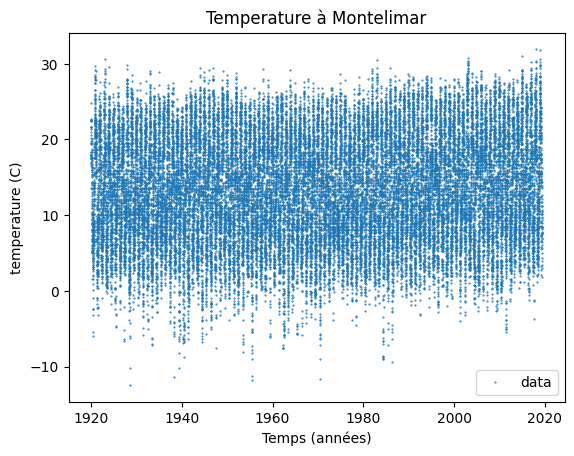

In [5]:
t_ = (t - t[0]) / 365.25 + 1920
plt.plot(t_, T, '.', label='data', markersize=1)
plt.xlabel('Temps (années)')
plt.ylabel('temperature (C)')
plt.title('Temperature à Montelimar')
plt.legend()
plt.show()

Il est difficile de lire quelconque augmentation de température sur la figure ci-dessus.

On va maintenant afficher la forme des données en fonction du temps pour la première année, afin de voir si la forme des données est bien sinusoïdale.

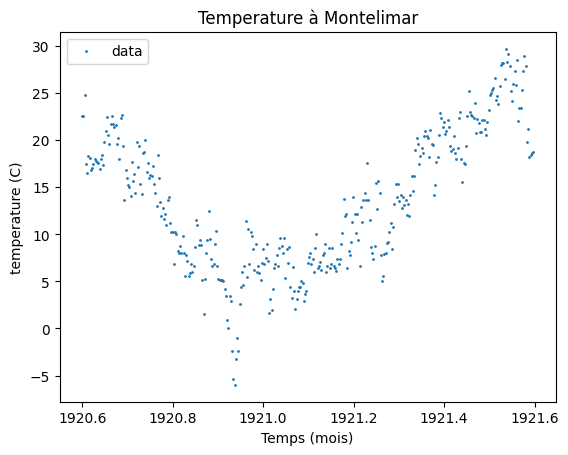

In [16]:
t_ = (t - t[0]) / 365.25 + 1920.6 # On remarque que les températures sont haute pour le début d'année, on rajoute donc un offset de 180 jours
plt.plot(t_[:365], T[:365], '.', label='data', markersize=2)
plt.xlabel('Temps (mois)')
plt.ylabel('temperature (C)')
plt.title('Temperature à Montelimar')
plt.legend()
plt.show()

On remarque une sinusoide assez bruitée.

Pour essayer de mettre en évidence un réchauffement climatique, on va afficher les moyenne annuelle des températures en fonction du temps.

In [17]:
dt = 365.25
nb_month = int(len(t) // dt)
T_month = np.zeros(nb_month)
t_month = np.linspace(0, nb_month, nb_month) + 1920
for i in range(0, nb_month):
    T_month[i] = np.mean(T[int(90+i*dt):int(90+(i+1)*dt)])

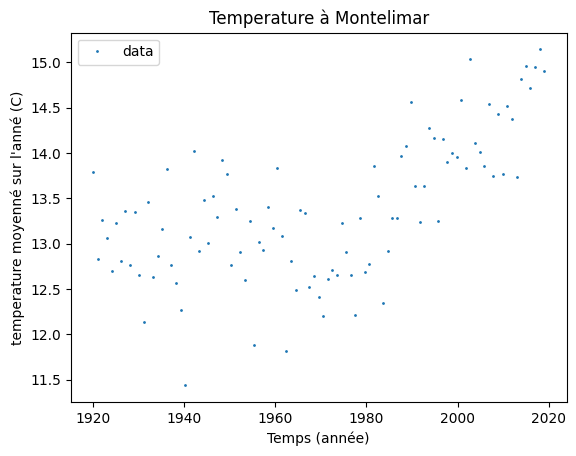

In [18]:
plt.plot(t_month, T_month, '.', label='data', markersize=2)
plt.xlabel('Temps (année)')
plt.ylabel("temperature moyenné sur l'anné (C)")
plt.title('Temperature à Montelimar')
plt.legend()
plt.show()

On remarque que la moyenne anuelle des température augement de 2°C en 100 ans, et qu'une augmentation de température est bien visible à partir de 1980.

# Modélisation par ajustement

Regardons maintenant les données de plus près et tentons de modéliser les variations saisonnières de la température.

In [36]:
annual_temp = np.split(T, [int(i*365.25) for i in range(1, 100)])

In [49]:
w = 2*np.pi/365.25

def var_sais(t, A, phi, B):
    return A*np.sin(w*t + phi) + B

Commençons par modéliser les variations saisonnières de la température en 1920.

[ 9.31889633  8.34705247 13.50885094]
[[ 5.14231799e-02  9.42887785e-06 -9.31855974e-05]
 [ 9.42887785e-06  5.93500742e-04  5.34549029e-06]
 [-9.31855974e-05  5.34549029e-06  2.57409390e-02]]


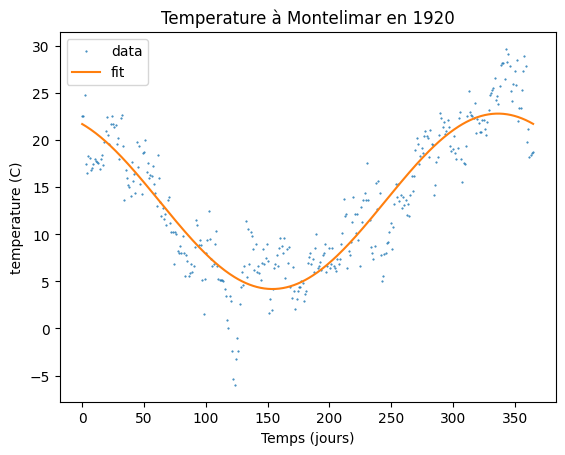

In [50]:
T_1920 = annual_temp[0]
t_1920 = np.linspace(0,365,365)
params, cov = curve_fit(var_sais, t_1920, T_1920,)
A, phi, B = params
print(params)
print(cov)
plt.plot(t_1920, T_1920, '.', label='data', markersize=1)
plt.plot(t_1920, var_sais(t_1920, A, phi, B), label='fit')
plt.xlabel('Temps (jours)')
plt.ylabel('temperature (C)')
plt.title('Temperature à Montelimar en 1920')
plt.legend()
plt.show()

Vérifions que le modèle sinusoïdal est bien adapté aux données en utilisant la méthode des moindres carrés.

In [51]:
def chi_2(data, model):
    return np.sum((data - model)**2)

chi_2_1920 = chi_2(T_1920, var_sais(t_1920, A, phi, B))
print(chi_2_1920)

3401.12154695849


Cette écart moyen quadratique est assez élévé, et indique donc que soit le modèle n'est pas adapté, soit que les données sont très bruitées.

Ici comme on parle de température, on peut supposer que les données sont bruitées.

Modélisons maintenant cette oscillation mais sur l'ensmble des années.

A = -9.01e+00 ± 2.39e-02; phi = 6.77e+00 ± 2.65e-03; B = 1.34e+01 ± 1.69e-02


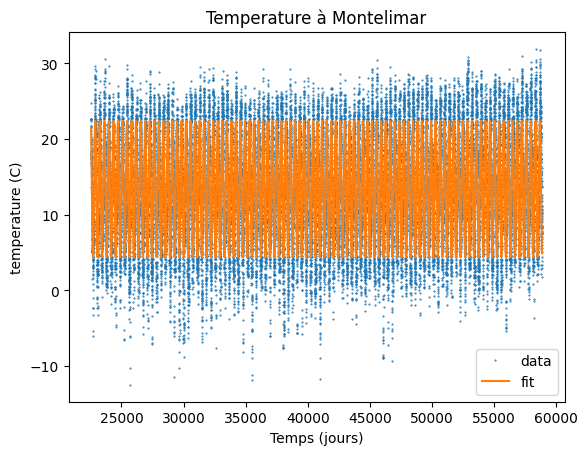

In [56]:
params, cov = curve_fit(var_sais, t, T,)
A, phi, B = params

print(f"A = {A:.2e} \u00B1 {np.sqrt(cov[0,0]):.2e}; phi = {phi:.2e} \u00B1 {np.sqrt(cov[1,1]):.2e}; B = {B:.2e} \u00B1 {np.sqrt(cov[2,2]):.2e}")
plt.plot(t, T, '.', label='data', markersize=1)
plt.plot(t, var_sais(t, A, phi, B), label='fit')
plt.xlabel('Temps (jours)')
plt.ylabel('temperature (C)')
plt.title('Temperature à Montelimar')
plt.legend()
plt.show()

Vérifiez que le modèle sinusoïdal est bien adapté aux données en utilisant la méthode des moindres carrés.

In [42]:
chi_2_sin = chi_2(T, var_sais(t, A, phi, B))
print(chi_2_sin)

3406400.489578332


On remarque que l'écart moyen quadratique est vraiment très élévé, même avec tout le bruit.

Il a bien l'oscillation saisonnière, mais on ne perçoit pas le réchauffement globale.

On va modifier le terme d'ajustement et ajouter un terme linéair pour commencer

A = -9.01e+00 ± 2.36e-02; phi = 6.77e+00 ± 2.62e-03; B = 1.15e+01 ± 6.69e-02; C = 1.69e+00 ± 5.82e-02


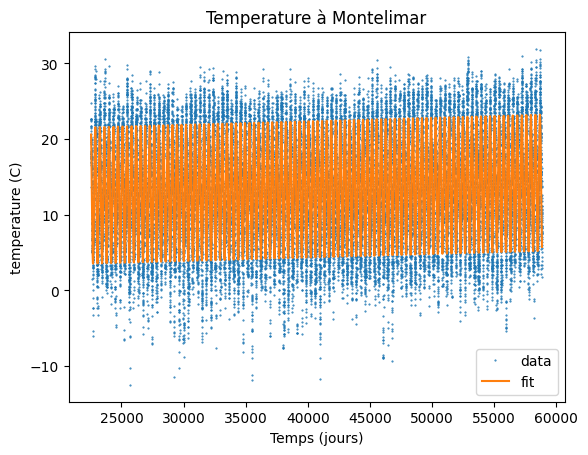

In [60]:
def var_sais(t, A, phi, B, C):
    return A*np.sin(w*t + phi) + B + C * t /(100 * 365.25)

params, cov = curve_fit(var_sais, t, T,)
A, phi, B, C = params
print(f"A = {A:.2e} \u00B1 {np.sqrt(cov[0,0]):.2e}; phi = {phi:.2e} \u00B1 {np.sqrt(cov[1,1]):.2e}; B = {B:.2e} \u00B1 {np.sqrt(cov[2,2]):.2e}; C = {C:.2e} \u00B1 {np.sqrt(cov[3,3]):.2e}")
plt.plot(t, T, '.', label='data', markersize=1)
plt.plot(t, var_sais(t, A, phi, B, C), label='fit')
plt.xlabel('Temps (jours)')
plt.ylabel('temperature (C)')
plt.title('Temperature à Montelimar')
plt.legend()
plt.show()

Vérifions que le modèle sinusoïdal et linéaire est bien adapté aux données en utilisant la méthode des moindres carrés.

In [61]:
chi2_sin_lin = chi_2(T, var_sais(t, A, phi, B, C))
print(chi2_sin_lin)

366755.71808236087


L'écart moyen quadratique est bien plus faible (d'un facteur 10), et on voit que le modèle est bien plus adapté.

D'après l'ajustement du paramètre C on a une augmentation de 1.6 °C par 100 ans

Essaion maintenant un ajustement quadratique c'est à dire:

$$ T(t) = A \sin{(\omega t + \phi)} + B + C t + D t^2 $$

A = -9.01e+00 ± 2.35e-02; phi = 6.77e+00 ± 2.60e-03; B = 1.68e+01 ± 2.70e-01; C = -8.56e+00 ± 5.06e-01; D = 4.60e+00 ± 2.25e-01


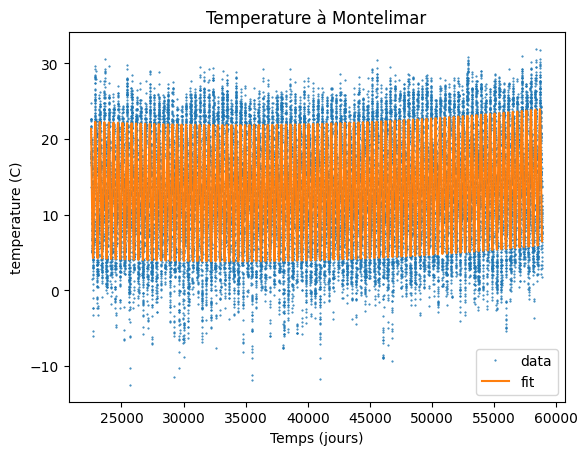

In [62]:
def var_sais(t, A, phi, B, C, D):
    return A*np.sin(w*t + phi) + B + C * t / (100 * 365.25) + D * t**2 / (100 * 365.25)**2

params, cov = curve_fit(var_sais, t, T,)
A, phi, B, C, D = params
print(f"A = {A:.2e} \u00B1 {np.sqrt(cov[0,0]):.2e}; phi = {phi:.2e} \u00B1 {np.sqrt(cov[1,1]):.2e}; B = {B:.2e} \u00B1 {np.sqrt(cov[2,2]):.2e}; C = {C:.2e} \u00B1 {np.sqrt(cov[3,3]):.2e}; D = {D:.2e} \u00B1 {np.sqrt(cov[4,4]):.2e}")
plt.plot(t, T, '.', label='data', markersize=1)
plt.plot(t, var_sais(t, A, phi, B, C, D), label='fit')
plt.xlabel('Temps (jours)')
plt.ylabel('temperature (C)')
plt.title('Temperature à Montelimar')
plt.legend()
plt.show()

Vériions que le modèle sinusoïdal et quadratique est bien adapté aux données en utilisant la méthode des moindres carrés.

In [63]:
chi2_sin_quad = chi_2(T, var_sais(t, A, phi, B, C, D))
print(chi2_sin_quad)

362598.8838218087


On remarque que l'écart moyen quadratique est encore plus faible, et on voit que le modèle est encore plus adapté.

Cependant on a beaucoup perdu en précision sur les paramètre ajustés.

De plus les paramètres C et D sont maintenant plus difficile à interpréter. (C étant négatif)

# Conclusion

On a pu montrer que les données de température de Montélimar montrent un réchauffement climatique significatif de 1.6 °C par 100 ans.

On a pu montrer que le modèle sinusoïdal et linéaire est bien adapté aux données, et que le modèle sinusoïdal et quadratique est encore plus adapté mais plus difficile à interpréter.